In [18]:
!pip install scikit-learn # TODO: add this to poetry

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import LogLocator
from matplotlib.colors import BoundaryNorm, ListedColormap
from sklearn.metrics import mean_absolute_percentage_error

### Degree Distribution

In [3]:

summary_path = "../scripts/really_final_100_degree.csv"
df = pd.read_csv(summary_path)

In [4]:
std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [5]:
features = ["mean", "std", "p10", "p25", "median", "p75", "p90"]
empirical_values = [126.1, 97, 34, 52, 97, 185, 236]
y_labels = [
    "Mean degree",
    "Standard deviation (of degree distribution)",
    r"$10^{\mathrm{th}}$ percentile degree",
    r"$25^{\mathrm{th}}$ percentile degree",
    "Median degree",
    r"$75^{\mathrm{th}}$ percentile degree",
    r"$90^{\mathrm{th}}$ percentile degree",
]
sigma_ticks = np.array([0.1, 0.125, 0.15, 0.175, 0.2]) #CHANGE HERE IF NEEDED
sigma_ticklabels = ["0.1", "0.125", "0.15", "0.175", "0.2"] #CHANGE HERE IF NEEDED

In [6]:
# Sample exactly one color per sigma value.
sigma_colors = plt.cm.turbo(
    np.linspace(0.15, 0.85, len(sigma_ticks))
)
cmap = ListedColormap(sigma_colors)

# Boundaries halfway between adjacent sigma values.
sigma_boundaries = np.concatenate([
    [sigma_ticks[0] - (sigma_ticks[1] - sigma_ticks[0]) / 2],
    (sigma_ticks[:-1] + sigma_ticks[1:]) / 2,
    [sigma_ticks[-1] + (sigma_ticks[-1] - sigma_ticks[-2]) / 2],
])

norm = BoundaryNorm(
    sigma_boundaries,
    cmap.N,
)

Plotting mean vs alpha


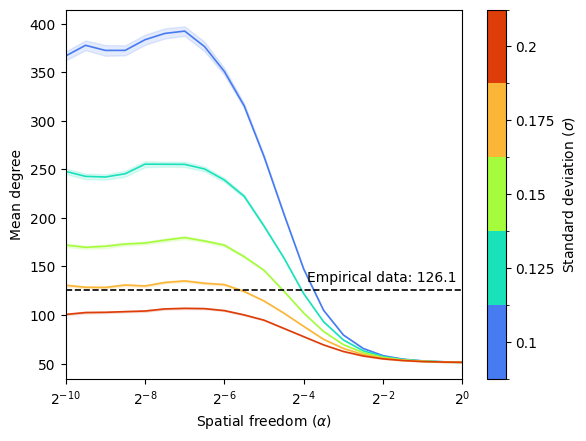

Plotting std vs alpha


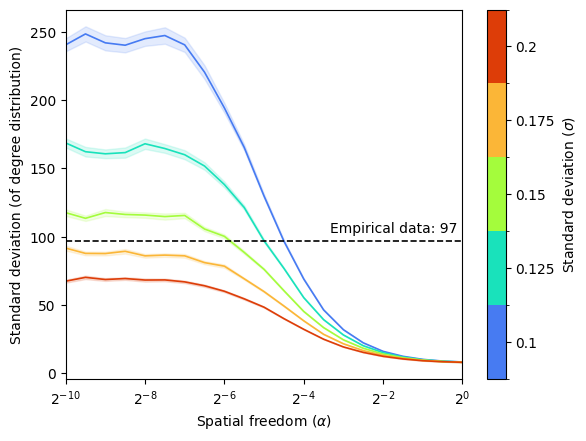

Plotting p10 vs alpha


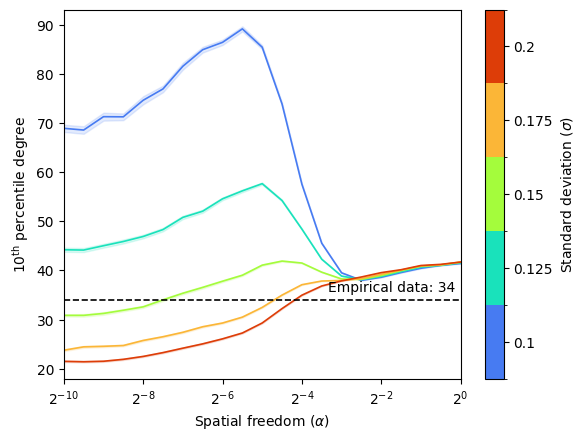

Plotting p25 vs alpha


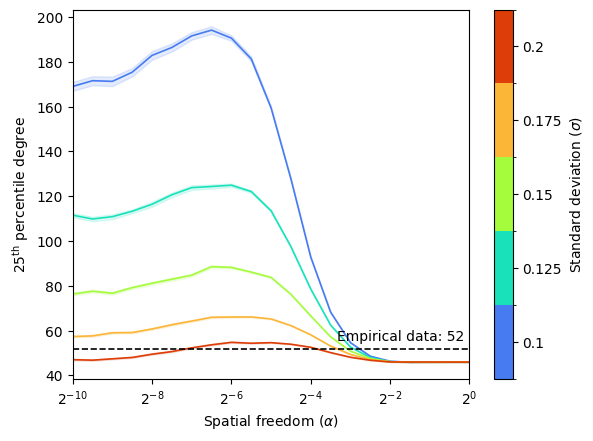

Plotting median vs alpha


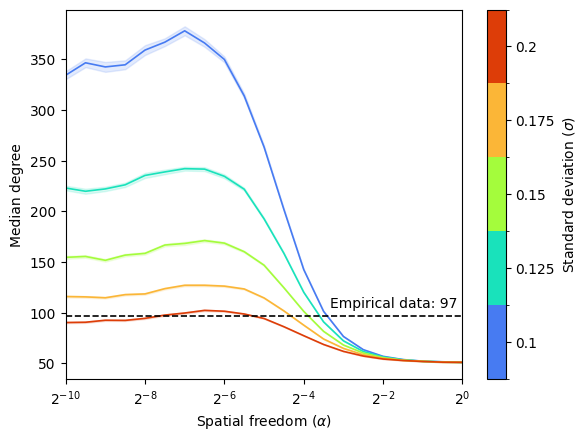

Plotting p75 vs alpha


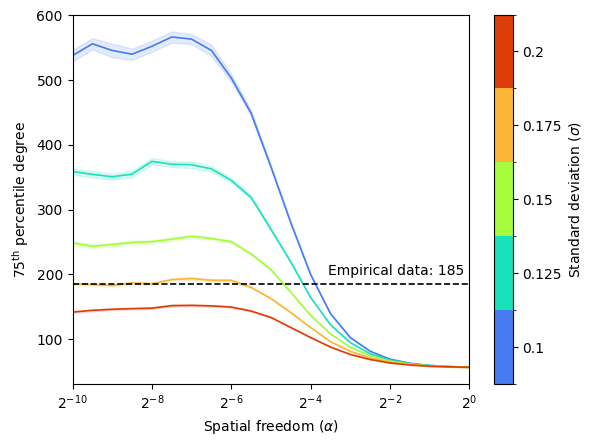

Plotting p90 vs alpha


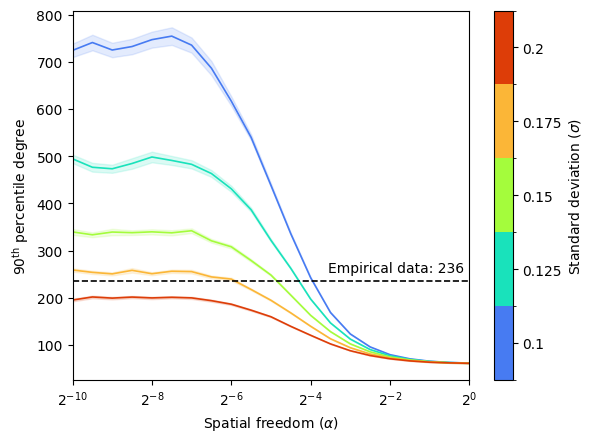

In [7]:
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

for feature, empirical_value, y_label in zip(
    features,
    empirical_values,
    y_labels,
):
    se_col = f"se_{feature}"

    if feature not in df.columns:
        raise KeyError(
            f"Column '{feature}' is missing from the CSV."
        )

    if se_col not in df.columns:
        raise KeyError(
            f"Column '{se_col}' is missing from the CSV."
        )

    print(f"Plotting {feature} vs alpha")

    fig, ax = plt.subplots()

    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        lower = values - ses
        upper = values + ses

        # Required because the y-axis is logarithmic.
        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
            & (values > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        # fill_between does not support non-positive values on a log axis.
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.fill_between(
            alphas,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        boundaries=sigma_boundaries,
        ticks=sigma_ticks,
        spacing="uniform",
    )
    cbar.set_label(r"Standard deviation ($\sigma$)")
    cbar.set_ticklabels(sigma_ticklabels)

    # Base-2 logarithmic alpha axis.
    ax.set_xscale("log", base=2)
    ax.set_xlim(2**-10, 1)
    ax.set_xticks(alpha_ticks)
    ax.set_xticklabels([
        rf"$2^{{{exponent}}}$"
        for exponent in tick_exponents
    ])

    # Empirical reference.
    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel(r"Spatial freedom ($\alpha$)")
    ax.set_ylabel(y_label)

    fig.savefig(
        f"fitting_degree_{feature}_vs_alpha_by_std_100.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

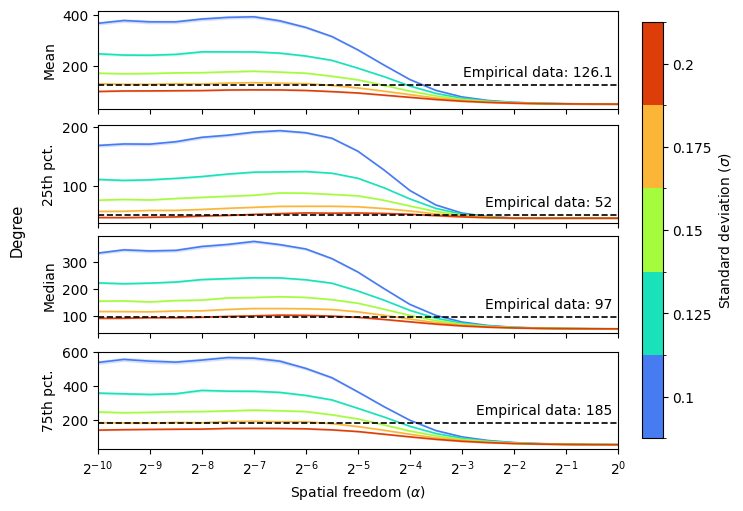

In [47]:
plot_features = [
    "mean",
    "p25",
    "median",
    "p75",
]

plot_se_columns = [
    "se_mean",
    "se_p25",
    "se_median",
    "se_p75",
]

plot_labels = [
    "Mean",
    "25th pct.",
    "Median",
    "75th pct.",
]

empirical_values = [
    126.1,
    52,
    97,
    185,
]

tick_exponents = np.arange(0, -11, -1)  # 0, -1, ..., -10
alpha_ticks = 2.0 ** tick_exponents

for column in plot_features + plot_se_columns:
    if column not in df.columns:
        raise KeyError(
            f"Column '{column}' is missing from the CSV."
        )

fig, axes = plt.subplots(
    4,
    1,
    figsize=(7, 5),
    sharex=True,
    constrained_layout=True,
)

fig.supylabel(
    "Degree",
    x=-0.04,
    y = 0.55,
    fontsize=10.5
)

"""fig.text(
    0.00,
    1.05,
    "Degree",
    ha="left",
    va="top",
    fontsize=10,
)"""

for (
    ax,
    feature,
    se_col,
    y_label,
    empirical_value,
) in zip(
    axes,
    plot_features,
    plot_se_columns,
    plot_labels,
    empirical_values,
):
    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        lower = values - ses
        upper = values + ses

        valid_band = (
            np.isfinite(alphas)
            & np.isfinite(lower)
            & np.isfinite(upper)
            & (alphas > 0)
        )

        ax.fill_between(
            alphas[valid_band],
            lower[valid_band],
            upper[valid_band],
            color=color,
            alpha=0.15,
        )

    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_ylabel(y_label)

# Shared base-2 logarithmic x-axis.
axes[-1].set_xscale("log", base=2)
axes[-1].set_xlim(2**-10, 1)
axes[-1].set_xticks(alpha_ticks)
axes[-1].set_xticklabels([
    rf"$2^{{{exponent}}}$"
    for exponent in tick_exponents
])
axes[-1].set_xlabel(r"Spatial freedom ($\alpha$)")

# Hide duplicate x tick labels on all but the bottom subplot.
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

# Shared colorbar on the right of all four plots.
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    pad=0.03,
    shrink=0.95,
)

cbar.set_label(r"Standard deviation ($\sigma$)")
cbar.set_ticks(std_values)
cbar.set_ticklabels(sigma_ticklabels)

fig.savefig(
    "fitting_degree_statistics_vs_alpha_by_std.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

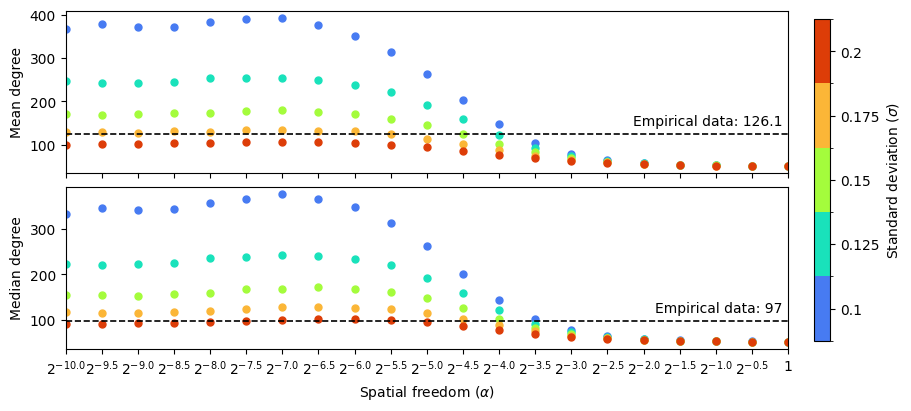

In [9]:
alpha_ticks = np.array([(1/2)**(i/2) for i in range(21)]) # COMMENT OUT
tick_exponents = [(-i/2) for i in range(21)] # COMMENT OUT

plot_features = [
    "mean",
    "median",
]

plot_se_columns = [
    "se_mean",
    "se_median",
]

plot_labels = [
    "Mean degree",
    "Median degree",
]

empirical_values = [
    126.1,
    97,
]

for column in plot_features + plot_se_columns:
    if column not in df.columns:
        raise KeyError(
            f"Column '{column}' is missing from the CSV."
        )

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 4),
    sharex=True,
    constrained_layout=True,
)

for (
    ax,
    feature,
    se_col,
    y_label,
    empirical_value,
) in zip(
    axes,
    plot_features,
    plot_se_columns,
    plot_labels,
    empirical_values,
):
    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
        )

        """ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )"""

        ax.scatter(
        alphas[valid_line],
        values[valid_line],
        color=color,
        s=25,
    )

        """lower = values - ses
        upper = values + ses

        valid_band = (
            np.isfinite(alphas)
            & np.isfinite(lower)
            & np.isfinite(upper)
            & (alphas > 0)
        )

        ax.fill_between(
            alphas[valid_band],
            lower[valid_band],
            upper[valid_band],
            color=color,
            alpha=0.15,
        )"""

    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_ylabel(y_label)

# Shared base-2 logarithmic x-axis.
axes[-1].set_xscale("log", base=2)
axes[-1].set_xlim(2**-10, 1)
axes[-1].set_xticks(alpha_ticks)
axes[-1].set_xticklabels([
    "1" if exponent == 0 else rf"$2^{{{exponent}}}$"
    for exponent in tick_exponents
])
axes[-1].set_xlabel(r"Spatial freedom ($\alpha$)")

# Hide duplicate x tick labels on the upper subplot.
axes[0].tick_params(labelbottom=False)

# Shared colorbar on the right of both plots.
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    pad=0.03,
    shrink=0.95,
)

cbar.set_label(r"Standard deviation ($\sigma$)")
cbar.set_ticks(std_values)
cbar.set_ticklabels(sigma_ticklabels)

fig.savefig(
    "fitting_mean_median_vs_alpha_by_std.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

### Mean Squared Error

In [10]:
empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
empirical_75th = 185

df_fit = df.copy()

df_fit["mean_sq_error"] = (
    df_fit["mean"] - empirical_mean
) ** 2

df_fit["median_sq_error"] = (
    df_fit["median"] - empirical_median
) ** 2

df_fit["25th_sq_error"] = (
    df_fit["p25"] - empirical_25th
) ** 2

df_fit["75th_sq_error"] = (
    df_fit["p75"] - empirical_75th
) ** 2

df_fit["average_mse"] = (
    df_fit["mean_sq_error"]
    + df_fit["median_sq_error"]
    + df_fit["25th_sq_error"]
    + df_fit["75th_sq_error"]
) / 4

best = df_fit.loc[df_fit["average_mse"].idxmin()]

top10 = (
    df_fit
    .sort_values("average_mse")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "median",
        "mean_sq_error",
        "median_sq_error",
        "p25",
        "25th_sq_error",
        "p75",
        "75th_sq_error",
        "average_mse",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean  median  mean_sq_error  median_sq_error   p25  25th_sq_error    p75  75th_sq_error  average_mse
   0.175 0.001953 128.366066  114.67       5.135055         312.2289 59.07        49.9849 182.65         5.5225    93.217839
   0.175 0.001381 128.558300  115.55       6.043239         344.1025 57.68        32.2624 184.12         0.7744    95.795635
   0.175 0.000977 130.565840  115.88      19.943727         356.4544 57.40        29.1600 185.39         0.1521   101.427557
   0.175 0.002762 130.848814  117.76      22.551234         430.9776 59.18        51.5524 186.66         2.7556   126.959209
   0.175 0.003906 129.843594  118.47      14.014496         460.9609 60.77        76.9129 185.33         0.1089   137.999299
   0.175 0.022097 124.218164  123.34       3.541307         693.7956 66.13       199.6569 179.77        27.3529   231.086677
   0.175 0.005524 133.492898  123.67      54.654941         711.2889 62.68       114.0624 191.70        44.8900   231.224060


In [11]:
from sklearn.metrics import mean_absolute_percentage_error

empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
empirical_75th = 185

df_fit = df.copy()


def scalar_mape(empirical_value, simulated_value):
    return mean_absolute_percentage_error(
        [empirical_value],
        [simulated_value],
    )


df_fit["mean_mape"] = df_fit["mean"].apply(
    lambda value: scalar_mape(empirical_mean, value)
)

df_fit["median_mape"] = df_fit["median"].apply(
    lambda value: scalar_mape(empirical_median, value)
)

df_fit["25th_mape"] = df_fit["p25"].apply(
    lambda value: scalar_mape(empirical_25th, value)
)

df_fit["75th_mape"] = df_fit["p75"].apply(
    lambda value: scalar_mape(empirical_75th, value)
)

df_fit["average_mape"] = df_fit[
    [
        "mean_mape",
        "median_mape",
        "25th_mape",
        "75th_mape",
    ]
].mean(axis=1)

best = df_fit.loc[df_fit["average_mape"].idxmin()]

top10 = (
    df_fit
    .sort_values("average_mape")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "mean_mape",
        "median",
        "median_mape",
        "p25",
        "25th_mape",
        "p75",
        "75th_mape",
        "average_mape",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean  mean_mape  median  median_mape   p25  25th_mape    p75  75th_mape  average_mape
   0.175 0.001381 128.558300   0.019495  115.55     0.191237 57.68   0.109231 184.12   0.004757      0.081180
   0.175 0.000977 130.565840   0.035415  115.88     0.194639 57.40   0.103846 185.39   0.002108      0.084002
   0.175 0.001953 128.366066   0.017970  114.67     0.182165 59.07   0.135962 182.65   0.012703      0.087200
   0.200 0.007812 106.833860   0.152785   99.63     0.027113 52.35   0.006731 151.94   0.178703      0.091333
   0.200 0.005524 106.253292   0.157389   97.60     0.006186 50.68   0.025385 151.58   0.180649      0.092402
   0.175 0.002762 130.848814   0.037659  117.76     0.214021 59.18   0.138077 186.66   0.008973      0.099682
   0.175 0.003906 129.843594   0.029688  118.47     0.221340 60.77   0.168654 185.33   0.001784      0.105366
   0.200 0.011049 106.558704   0.154967  102.24     0.054021 53.71   0.032885 151.20   0.182703      0.106144
   0.200 0

In [12]:
# all at once
from sklearn.metrics import mean_absolute_percentage_error

empirical_values = np.array([
    126.1,  # mean
    52,     # 25th percentile
    97,     # median
    185,    # 75th percentile
])

def combined_mape(row):
    simulated_values = np.array([
        row["mean"],
        row["p25"],
        row["median"],
        row["p75"],
    ])

    return mean_absolute_percentage_error(
        empirical_values,
        simulated_values,
    )

df_fit = df.copy()

df_fit["mape"] = df_fit.apply(
    combined_mape,
    axis=1,
)

top10 = (
    df_fit
    .sort_values("mape")
    .head(10)
    [[
        "param_0",
        "param_1",
        "mean",
        "p25",
        "median",
        "p75",
        "mape",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean   p25  median    p75     mape
   0.175 0.001381 128.558300 57.68  115.55 184.12 0.081180
   0.175 0.000977 130.565840 57.40  115.88 185.39 0.084002
   0.175 0.001953 128.366066 59.07  114.67 182.65 0.087200
   0.200 0.007812 106.833860 52.35   99.63 151.94 0.091333
   0.200 0.005524 106.253292 50.68   97.60 151.58 0.092402
   0.175 0.002762 130.848814 59.18  117.76 186.66 0.099682
   0.175 0.003906 129.843594 60.77  118.47 185.33 0.105366
   0.200 0.011049 106.558704 53.71  102.24 151.20 0.106144
   0.200 0.003906 104.081316 49.52   94.38 147.64 0.112815
   0.200 0.015625 104.515200 54.81  101.40 149.33 0.115846


In [13]:
def maximum_ape(row):
    simulated_values = np.array([
        row["mean"],
        row["p25"],
        row["median"],
        row["p75"],
    ])

    absolute_percentage_errors = np.abs(
        simulated_values - empirical_values
    ) / empirical_values

    return np.max(absolute_percentage_errors)


df_fit["max_ape"] = df_fit.apply(
    maximum_ape,
    axis=1,
)

top10 = (
    df_fit
    .sort_values("max_ape")
    .head(10)
    [[
        "param_0",
        "param_1",
        "mean",
        "p25",
        "median",
        "p75",
        "max_ape",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean   p25  median    p75  max_ape
   0.200 0.007812 106.833860 52.35   99.63 151.94 0.178703
   0.200 0.005524 106.253292 50.68   97.60 151.58 0.180649
   0.175 0.001953 128.366066 59.07  114.67 182.65 0.182165
   0.200 0.011049 106.558704 53.71  102.24 151.20 0.182703
   0.175 0.001381 128.558300 57.68  115.55 184.12 0.191237
   0.200 0.015625 104.515200 54.81  101.40 149.33 0.192811
   0.175 0.000977 130.565840 57.40  115.88 185.39 0.194639
   0.200 0.003906 104.081316 49.52   94.38 147.64 0.201946
   0.200 0.002762 103.455264 48.06   92.35 146.94 0.205730
   0.200 0.001953 102.762642 47.45   92.52 145.94 0.211135


In [14]:
from sklearn.metrics import root_mean_squared_error

empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
empirical_75th = 185

df_fit = df.copy()


def scalar_rmse(empirical_value, simulated_value):
    return root_mean_squared_error(
        [empirical_value],
        [simulated_value],
    )


df_fit["mean_rmse"] = df_fit["mean"].apply(
    lambda value: scalar_rmse(empirical_mean, value)
)

df_fit["median_rmse"] = df_fit["median"].apply(
    lambda value: scalar_rmse(empirical_median, value)
)

df_fit["25th_rmse"] = df_fit["p25"].apply(
    lambda value: scalar_rmse(empirical_25th, value)
)

df_fit["75th_rmse"] = df_fit["p75"].apply(
    lambda value: scalar_rmse(empirical_75th, value)
)

df_fit["average_rmse"] = df_fit[
    [
        "mean_rmse",
        "median_rmse",
        "25th_rmse",
        "75th_rmse",
    ]
].mean(axis=1)

best = df_fit.loc[df_fit["average_rmse"].idxmin()]

top10 = (
    df_fit
    .sort_values("average_rmse")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "mean_rmse",
        "median",
        "median_rmse",
        "p25",
        "25th_rmse",
        "p75",
        "75th_rmse",
        "average_rmse",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean  mean_rmse  median  median_rmse   p25  25th_rmse    p75  75th_rmse  average_rmse
   0.175 0.001381 128.558300   2.458300  115.55        18.55 57.68       5.68 184.12       0.88      6.892075
   0.175 0.000977 130.565840   4.465840  115.88        18.88 57.40       5.40 185.39       0.39      7.283960
   0.175 0.001953 128.366066   2.266066  114.67        17.67 59.07       7.07 182.65       2.35      7.339016
   0.175 0.003906 129.843594   3.743594  118.47        21.47 60.77       8.77 185.33       0.33      8.578399
   0.175 0.002762 130.848814   4.748814  117.76        20.76 59.18       7.18 186.66       1.66      8.587204
   0.175 0.022097 124.218164   1.881836  123.34        26.34 66.13      14.13 179.77       5.23     11.895459
   0.175 0.005524 133.492898   7.392898  123.67        26.67 62.68      10.68 191.70       6.70     12.860724
   0.175 0.015625 131.265128   5.165128  126.15        29.15 66.11      14.11 190.62       5.62     13.511282
   0.200 0

In [15]:
#empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
empirical_75th = 185

df_fit = df.copy()

df_fit["mean_sq_error"] = (
    df_fit["mean"] - empirical_mean
) ** 2

"""df_fit["median_sq_error"] = (
    df_fit["median"] - empirical_median
) ** 2"""

df_fit["25th_sq_error"] = (
    df_fit["p25"] - empirical_25th
) ** 2

df_fit["75th_sq_error"] = (
    df_fit["p75"] - empirical_75th
) ** 2

df_fit["average_mse"] = (
    df_fit["mean_sq_error"]
    + df_fit["25th_sq_error"]
    + df_fit["75th_sq_error"]
) / 3

best = df_fit.loc[df_fit["average_mse"].idxmin()]

top10 = (
    df_fit
    .sort_values("average_mse")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "mean_sq_error",
        "p25",
        "25th_sq_error",
        "p75",
        "75th_sq_error",
        "average_mse",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean  mean_sq_error   p25  25th_sq_error    p75  75th_sq_error  average_mse
   0.175 0.001381 128.558300       6.043239 57.68        32.2624 184.12         0.7744    13.026680
   0.175 0.000977 130.565840      19.943727 57.40        29.1600 185.39         0.1521    16.418609
   0.175 0.001953 128.366066       5.135055 59.07        49.9849 182.65         5.5225    20.214152
   0.175 0.002762 130.848814      22.551234 59.18        51.5524 186.66         2.7556    25.619745
   0.175 0.003906 129.843594      14.014496 60.77        76.9129 185.33         0.1089    30.345432
   0.175 0.005524 133.492898      54.654941 62.68       114.0624 191.70        44.8900    71.202447
   0.175 0.022097 124.218164       3.541307 66.13       199.6569 179.77        27.3529    76.850369
   0.175 0.015625 131.265128      26.678547 66.11       199.0921 190.62        31.5844    85.785016
   0.175 0.011049 132.672256      43.194549 65.98       195.4404 190.70        32.4900    90.374983


In [16]:
empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
empirical_75th = 185

df_fit = df.copy()

df_fit["mean_sq_error"] = (
    df_fit["mean"] - empirical_mean
) ** 2

df_fit["average_mse"] = (
    df_fit["mean_sq_error"]
)

best = df_fit.loc[df_fit["average_mse"].idxmin()]

top10 = (
    df_fit
    .sort_values("average_mse")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "mean_sq_error",
        "average_mse",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean  mean_sq_error  average_mse
   0.150 0.044194 124.455518       2.704321     2.704321
   0.175 0.022097 124.218164       3.541307     3.541307
   0.175 0.001953 128.366066       5.135055     5.135055
   0.175 0.001381 128.558300       6.043239     6.043239
   0.175 0.003906 129.843594      14.014496    14.014496
   0.125 0.062500 121.901098      17.630778    17.630778
   0.175 0.000977 130.565840      19.943727    19.943727
   0.175 0.002762 130.848814      22.551234    22.551234
   0.175 0.015625 131.265128      26.678547    26.678547
   0.175 0.011049 132.672256      43.194549    43.194549


In [17]:
sigma = 0.15
alpha = 2**-4

print(
    df_fit.loc[
        np.isclose(df_fit["param_0"], sigma)
        & np.isclose(df_fit["param_1"], alpha),
        [
            "param_0",
            "param_1",
            "mean",
            "median",
            "average_mse",
        ],
    ]
)

    param_0  param_1        mean  median  average_mse
54     0.15   0.0625  101.979568  101.26    581.79524


In [18]:
feature = "median"

mse_by_std = {}

for std in std_values:
    sub = (
        df[df[std_col] == std]
        .sort_values(alpha_col)
    )

    values = sub[feature].to_numpy(dtype=float)

    mse = np.mean((values - empirical_value)**2)
    mse_by_std[std] = mse

print(mse_by_std)

{np.float64(0.1): np.float64(33109.871819047614), np.float64(0.125): np.float64(9709.070276190478), np.float64(0.15): np.float64(2719.969476190476), np.float64(0.175): np.float64(922.7869904761905), np.float64(0.2): np.float64(684.6756142857142)}


### Mean Absolute Error

In [19]:
df_fit["average_mae"] = (
    np.abs(df_fit["mean"] - empirical_mean)
    + np.abs(df_fit["median"] - empirical_median)
    + np.abs(df_fit["p25"] - empirical_25th)
    + np.abs(df_fit["p75"] - empirical_75th)
) / 4

best_mae = df_fit.loc[df_fit["average_mae"].idxmin()]

top10_mae = (
    df_fit
    .sort_values("average_mae")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "median",
        "average_mae",
    ]]
)

print(top10_mae.to_string(index=False))

 param_0  param_1       mean  median  average_mae
   0.175 0.001381 128.558300  115.55     6.892075
   0.175 0.000977 130.565840  115.88     7.283960
   0.175 0.001953 128.366066  114.67     7.339016
   0.175 0.003906 129.843594  118.47     8.578399
   0.175 0.002762 130.848814  117.76     8.587204
   0.175 0.022097 124.218164  123.34    11.895459
   0.175 0.005524 133.492898  123.67    12.860724
   0.175 0.015625 131.265128  126.15    13.511282
   0.200 0.005524 106.253292   97.60    13.796677
   0.200 0.007812 106.833860   99.63    13.826535


In [20]:
sigma = 0.15
alpha = 2**-4

print(
    df_fit.loc[
        np.isclose(df_fit["param_0"], sigma)
        & np.isclose(df_fit["param_1"], alpha),
        [
            "param_0",
            "param_1",
            "mean",
            "median",
            "average_mse",
            "average_mae",
        ],
    ]
)

    param_0  param_1        mean  median  average_mse  average_mae
54     0.15   0.0625  101.979568  101.26    581.79524    22.852608


In [21]:
feature = "median"

mae_by_std = {}

for std in std_values:
    sub = (
        df[df[std_col] == std]
        .sort_values(alpha_col)
    )

    values = sub[feature].to_numpy(dtype=float)

    mae = np.mean(np.abs(values - empirical_value))
    mae_by_std[std] = mae

print(mae_by_std)

{np.float64(0.1): np.float64(148.80666666666667), np.float64(0.125): np.float64(85.78476190476192), np.float64(0.15): np.float64(48.86285714285714), np.float64(0.175): np.float64(27.986666666666668), np.float64(0.2): np.float64(19.05952380952381)}


### Generating Summary Tables

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error


def generate_degree_statistics_latex_table(
    df,
    output_path,
    std_col="std",
    alpha_col="alpha",
    mape_col=None,
    min_exponent=-10,
    max_exponent=0,
    value_decimals=1,
    mape_decimals=2,
):
    """
    Generate an Overleaf table of fitted degree statistics.

    The table has columns:

        sigma | alpha | mean | 25th | median | 75th | MAPE

    Multiple alpha rows belonging to the same sigma are grouped using
    LaTeX's \\multirow command.

    Only alpha values equal to 2^k for integer exponents k between
    min_exponent and max_exponent are included.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing sigma, alpha, and degree statistics.

    output_path : str or pathlib.Path
        Destination of the generated .tex file.

    std_col : str
        Column containing sigma values.

    alpha_col : str
        Column containing alpha values.

    mape_col : str or None
        Existing MAPE column to use. When None, MAPE is calculated from
        mean, p25, median, and p75.

    min_exponent, max_exponent : int
        Inclusive range of integer base-2 alpha exponents.

    value_decimals : int
        Decimal places used for degree statistics.

    mape_decimals : int
        Decimal places used for MAPE percentages.

    Returns
    -------
    table_df : pandas.DataFrame
        Filtered data used in the table.

    latex : str
        Complete LaTeX table code.
    """

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    degree_columns = [
        "mean",
        "p25",
        "median",
        "p75",
    ]

    required_columns = [
        std_col,
        alpha_col,
        *degree_columns,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            "Missing required columns: "
            + ", ".join(missing_columns)
        )

    empirical = np.array(
        [126.1, 52.0, 97.0, 185.0],
        dtype=float,
    )

    table_df = df.copy()

    # --------------------------------------------------------------
    # Match each alpha to an integer base-2 exponent
    # --------------------------------------------------------------

    alpha_values = table_df[alpha_col].to_numpy(dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        exponent_values = np.log2(alpha_values)

    rounded_exponents = np.rint(exponent_values)

    valid_alpha = (
        np.isfinite(exponent_values)
        & (alpha_values > 0)
        & np.isclose(
            exponent_values,
            rounded_exponents,
            atol=1e-8,
            rtol=0,
        )
        & (rounded_exponents >= min_exponent)
        & (rounded_exponents <= max_exponent)
    )

    table_df = table_df.loc[valid_alpha].copy()

    table_df["alpha_exponent"] = (
        rounded_exponents[valid_alpha].astype(int)
    )

    # --------------------------------------------------------------
    # Calculate MAPE if an existing column was not supplied
    # --------------------------------------------------------------

    if mape_col is None:
        simulated_values = table_df[
            degree_columns
        ].to_numpy(dtype=float)

        table_df["mape"] = [
            mean_absolute_percentage_error(
                empirical,
                simulated_row,
            )
            for simulated_row in simulated_values
        ]

        mape_col_used = "mape"
    else:
        if mape_col not in table_df.columns:
            raise KeyError(
                f"MAPE column '{mape_col}' is missing."
            )

        mape_col_used = mape_col

    # Convert from a fraction to a percentage.
    table_df["mape_percent"] = (
        100.0 * table_df[mape_col_used].astype(float)
    )

    # Group sigma values and list alpha from 1 down to 2^-10.
    table_df = table_df.sort_values(
        [std_col, "alpha_exponent"],
        ascending=[True, False],
    ).reset_index(drop=True)

    # --------------------------------------------------------------
    # Construct the LaTeX body
    # --------------------------------------------------------------

    body_lines = []

    grouped = table_df.groupby(
        std_col,
        sort=True,
        dropna=False,
    )

    for sigma, sigma_group in grouped:
        sigma_group = sigma_group.reset_index(drop=True)
        n_rows = len(sigma_group)

        for row_index, row in sigma_group.iterrows():
            exponent = int(row["alpha_exponent"])

            alpha_latex = rf"$2^{{{exponent}}}$"

            if row_index == 0:
                sigma_entry = (
                    rf"\multirow{{{n_rows}}}{{*}}"
                    rf"{{$ {sigma:g} $}}"
                )
            else:
                sigma_entry = ""

            mean_text = f"{row['mean']:.{value_decimals}f}"
            p25_text = f"{row['p25']:.{value_decimals}f}"
            median_text = f"{row['median']:.{value_decimals}f}"
            p75_text = f"{row['p75']:.{value_decimals}f}"

            mape_text = (
                f"{row['mape_percent']:.{mape_decimals}f}"
                r"\%"
            )

            body_lines.append(
                f"{sigma_entry} & "
                f"{alpha_latex} & "
                f"{mean_text} & "
                f"{p25_text} & "
                f"{median_text} & "
                f"{p75_text} & "
                f"{mape_text} \\\\"
            )

        # Separator between sigma groups.
        body_lines.append(r"\midrule")

    # Remove the final unnecessary separator.
    if body_lines and body_lines[-1] == r"\midrule":
        body_lines.pop()

    body = "\n".join(body_lines)

    latex = rf"""
\begin{{table}}[htbp]
    \centering
    \caption{{Degree statistics obtained for different values of spatial freedom $\alpha$ and standard deviation of the node embedding distribution $\sigma$. MAPE is calculated relative to the empirical mean, 25th percentile, median, and 75th percentile.}}
    \label{{tab:degree-statistics-fitting}}
    \begin{{tabular}}{{ccrrrrr}}
        \toprule
        $\sigma$ &
        $\alpha$ &
        Mean &
        25th &
        Median &
        75th &
        MAPE \\
        \midrule
{body}
        \bottomrule
    \end{{tabular}}
\end{{table}}
""".strip()

    output_path.write_text(
        latex,
        encoding="utf-8",
    )

    return table_df, latex

In [23]:
table_df, latex_table = generate_degree_statistics_latex_table(
    df=df,
    output_path="degree_statistics_table.tex",
    std_col=std_col,
    alpha_col=alpha_col,
    mape_col=None,
)

print(latex_table)

\begin{table}[htbp]
    \centering
    \caption{Degree statistics obtained for different values of spatial freedom $\alpha$ and standard deviation of the node embedding distribution $\sigma$. MAPE is calculated relative to the empirical mean, 25th percentile, median, and 75th percentile.}
    \label{tab:degree-statistics-fitting}
    \begin{tabular}{ccrrrrr}
        \toprule
        $\sigma$ &
        $\alpha$ &
        Mean &
        25th &
        Median &
        75th &
        MAPE \\
        \midrule
\multirow{11}{*}{$ 0.1 $} & $2^{0}$ & 51.4 & 46.0 & 51.0 & 56.6 & 46.90\% \\
 & $2^{-1}$ & 52.7 & 46.0 & 52.1 & 59.1 & 46.01\% \\
 & $2^{-2}$ & 58.1 & 46.4 & 56.9 & 68.8 & 42.23\% \\
 & $2^{-3}$ & 79.4 & 54.7 & 76.5 & 102.2 & 27.01\% \\
 & $2^{-4}$ & 147.2 & 92.8 & 142.5 & 199.6 & 37.51\% \\
 & $2^{-5}$ & 263.1 & 159.5 & 263.4 & 366.0 & 146.16\% \\
 & $2^{-6}$ & 350.8 & 190.6 & 349.7 & 503.4 & 219.33\% \\
 & $2^{-7}$ & 392.4 & 191.6 & 377.9 & 563.4 & 243.45\% \\
 & $2^{-8}$ & 383.5 & 

In [34]:
from pathlib import Path

import numpy as np
import pandas as pd


def generate_degree_statistics_latex_table(
    df,
    output_path,
    std_col="std",
    alpha_col="alpha",
    min_exponent=-10,
    max_exponent=0,
    value_decimals=1,
    mse_decimals=2,
):
    """
    Generate an Overleaf table of fitted degree statistics.

    The table columns are:

        sigma | alpha | mean | 25th | median | 75th | MSE

    Multiple alpha rows belonging to the same sigma are grouped using
    LaTeX's \\multirow command.

    Only alpha values equal to 2^k for integer exponents k between
    min_exponent and max_exponent are included.

    MSE is calculated as the average squared error across:

        mean, 25th percentile, median, 75th percentile

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing sigma, alpha, and degree statistics.

    output_path : str or pathlib.Path
        Destination of the generated .tex file.

    std_col : str
        Column containing sigma values.

    alpha_col : str
        Column containing alpha values.

    min_exponent, max_exponent : int
        Inclusive range of integer base-2 alpha exponents.

    value_decimals : int
        Decimal places used for degree statistics.

    mse_decimals : int
        Decimal places used for MSE.

    Returns
    -------
    table_df : pandas.DataFrame
        Filtered data used in the table, including the calculated MSE.

    latex : str
        Complete LaTeX table code.
    """

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    degree_columns = [
        "mean",
        "p25",
        "median",
        "p75",
    ]

    required_columns = [
        std_col,
        alpha_col,
        *degree_columns,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            "Missing required columns: "
            + ", ".join(missing_columns)
        )

    table_df = df.copy()

    # --------------------------------------------------------------
    # Match each alpha to an integer base-2 exponent
    # --------------------------------------------------------------

    alpha_values = table_df[alpha_col].to_numpy(dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        exponent_values = np.log2(alpha_values)

    rounded_exponents = np.rint(exponent_values)

    valid_alpha = (
        np.isfinite(exponent_values)
        & (alpha_values > 0)
        & np.isclose(
            exponent_values,
            rounded_exponents,
            atol=1e-8,
            rtol=0,
        )
        & (rounded_exponents >= min_exponent)
        & (rounded_exponents <= max_exponent)
    )

    table_df = table_df.loc[valid_alpha].copy()

    table_df["alpha_exponent"] = (
        rounded_exponents[valid_alpha].astype(int)
    )

    # --------------------------------------------------------------
    # Calculate overall MSE
    # --------------------------------------------------------------

    empirical_mean = 126.1
    empirical_25th = 52.0
    empirical_median = 97.0
    empirical_75th = 185.0

    table_df["mean_sq_error"] = (
        table_df["mean"] - empirical_mean
    ) ** 2

    table_df["25th_sq_error"] = (
        table_df["p25"] - empirical_25th
    ) ** 2

    table_df["median_sq_error"] = (
        table_df["median"] - empirical_median
    ) ** 2

    table_df["75th_sq_error"] = (
        table_df["p75"] - empirical_75th
    ) ** 2

    table_df["mse"] = (
        table_df["mean_sq_error"]
        + table_df["25th_sq_error"]
        + table_df["median_sq_error"]
        + table_df["75th_sq_error"]
    ) / 4

    # Group sigma values and list alpha from 1 down to 2^-10.
    table_df = table_df.sort_values(
        [std_col, "alpha_exponent"],
        ascending=[True, False],
    ).reset_index(drop=True)

    # --------------------------------------------------------------
    # Construct the LaTeX body
    # --------------------------------------------------------------

    body_lines = []

    grouped = table_df.groupby(
        std_col,
        sort=True,
        dropna=False,
    )

    for sigma, sigma_group in grouped:
        sigma_group = sigma_group.reset_index(drop=True)
        n_rows = len(sigma_group)

        for row_index, row in sigma_group.iterrows():
            exponent = int(row["alpha_exponent"])

            alpha_latex = rf"$2^{{{exponent}}}$"

            if row_index == 0:
                sigma_entry = (
                    rf"\multirow{{{n_rows}}}{{*}}"
                    rf"{{$ {sigma:g} $}}"
                )
            else:
                sigma_entry = ""

            mean_text = (
                f"{row['mean']:.{value_decimals}f}"
            )

            p25_text = (
                f"{row['p25']:.{value_decimals}f}"
            )

            median_text = (
                f"{row['median']:.{value_decimals}f}"
            )

            p75_text = (
                f"{row['p75']:.{value_decimals}f}"
            )

            mse_text = (
                f"{row['mse']:.{mse_decimals}f}"
            )

            body_lines.append(
                f"{sigma_entry} & "
                f"{alpha_latex} & "
                f"{mean_text} & "
                f"{p25_text} & "
                f"{median_text} & "
                f"{p75_text} & "
                f"{mse_text} \\\\"
            )

        body_lines.append(r"\midrule")

    # Remove the final unnecessary separator.
    if body_lines and body_lines[-1] == r"\midrule":
        body_lines.pop()

    body = "\n".join(body_lines)

    latex = rf"""
\begin{{table}}[H]
    \centering
    \footnotesize
    \caption{{
        Degree statistics obtained for different values of the spatial freedom $\alpha$ and the standard deviation of the node embedding distribution $\sigma$. The MSE is calculated relative to the empirical mean, 25th percentile, median, and 75th percentile values of the degree distribution reported for the population-scale social network of the Netherlands in the year 2018.
    }}
    \label{{tab:degree-statistics-fitting}}
    \begin{{tabular}}{{ccrrrrr}}
        \toprule
        Standard deviation ($\sigma$) &
        Spatial freedom ($\alpha$) &
        Mean &
        25th &
        Median &
        75th &
        MSE \\
        \midrule
{body}
        \bottomrule
    \end{{tabular}}
\end{{table}}
""".strip()

    output_path.write_text(
        latex,
        encoding="utf-8",
    )

    return table_df, latex

In [35]:
table_df, latex_table = generate_degree_statistics_latex_table(
    df=df,
    output_path="degree_statistics_mse_table.tex",
    std_col=std_col,
    alpha_col=alpha_col,
)

print(latex_table)

\begin{table}[H]
    \centering
    \footnotesize
    \caption{
        Degree statistics obtained for different values of the spatial freedom $\alpha$ and the standard deviation of the node embedding distribution $\sigma$. The MSE is calculated relative to the empirical mean, 25th percentile, median, and 75th percentile values of the degree distribution reported for the population-scale social network of the Netherlands in the year 2018.
    }
    \label{tab:degree-statistics-fitting}
    \begin{tabular}{ccrrrrr}
        \toprule
        Standard deviation ($\sigma$) &
        Spatial freedom ($\alpha$) &
        Mean &
        25th &
        Median &
        75th &
        MSE \\
        \midrule
\multirow{11}{*}{$ 0.1 $} & $2^{0}$ & 51.4 & 46.0 & 51.0 & 56.6 & 6055.36 \\
 & $2^{-1}$ & 52.7 & 46.0 & 52.1 & 59.1 & 5817.71 \\
 & $2^{-2}$ & 58.1 & 46.4 & 56.9 & 68.8 & 4943.26 \\
 & $2^{-3}$ & 79.4 & 54.7 & 76.5 & 102.2 & 2368.12 \\
 & $2^{-4}$ & 147.2 & 92.8 & 142.5 & 199.6 & 1098.78 \\